# Docling End-to-End Document Processing

## Overview
This notebook demonstrates the use of the Docling library to process various document formats, including PDF, PPTX, and images. It covers:
- Simple PDF to Markdown conversion
- Multi-format document conversion
- Figure and table extraction
- Full-page OCR for scanned documents
- Translation of extracted text to German

## Prerequisites
- Input files: `2408.09869v5.pdf`, `My_Haystack_Learning_Summary.pptx`, `file-7mNhEGHpd0.png`
- Tesseract installed for OCR
- Internet access for model downloads and Google Translate

## Instructions
Run the cells in sequence. Ensure input files are in the `/content/` directory or update paths accordingly.

This section installs all necessary libraries for document parsing, OCR, translation, and semantic search using the Docling library and its dependencies. Run this before executing the rest of the notebook.

In [14]:
!python --version

Python 3.12.13


In [3]:
# Install required dependencies
!pip install docling[all]
!pip install rapidocr onnxruntime tesserocr pdf2image docling-core pandas
!pip install sentence-transformers langchain-community langchain-huggingface faiss-cpu
!pip install googletrans==4.0.0-rc1
!pip install --upgrade huggingface_hub httpx

  Using cached httpx-0.13.3-py3-none-any.whl.metadata (25 kB)
  Using cached httpcore-0.9.1-py3-none-any.whl.metadata (4.6 kB)
  Using cached h11-0.9.0-py2.py3-none-any.whl.metadata (8.1 kB)
Using cached httpx-0.13.3-py3-none-any.whl (55 kB)
Using cached httpcore-0.9.1-py3-none-any.whl (42 kB)
Using cached h11-0.9.0-py2.py3-none-any.whl (53 kB)
  Attempting uninstall: h11
    Found existing installation: h11 0.16.0
    Uninstalling h11-0.16.0:
      Successfully uninstalled h11-0.16.0
  Attempting uninstall: httpcore
    Found existing installation: httpcore 1.0.9
    Uninstalling httpcore-1.0.9:
      Successfully uninstalled httpcore-1.0.9
  Attempting uninstall: httpx
    Found existing installation: httpx 0.28.1
    Uninstalling httpx-0.28.1:
      Successfully uninstalled httpx-0.28.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
huggingface-hub 1.20.1 r

  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
Using cached httpx-0.28.1-py3-none-any.whl (73 kB)
Using cached httpcore-1.0.9-py3-none-any.whl (78 kB)
Using cached h11-0.16.0-py3-none-any.whl (37 kB)
  Attempting uninstall: h11
    Found existing installation: h11 0.9.0
    Uninstalling h11-0.9.0:
      Successfully uninstalled h11-0.9.0
  Attempting uninstall: httpcore
    Found existing installation: httpcore 0.9.1
    Uninstalling httpcore-0.9.1:
      Successfully uninstalled httpcore-0.9.1
  Attempting uninstall: httpx
    Found existing installation: httpx 0.13.3
    Uninstalling httpx-0.13.3:
      Successfully uninstalled httpx-0.13.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
googletrans 4.0.0rc1 requires htt

In [5]:
!pip install --upgrade huggingface_hub httpx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 4.7 MB/s eta 0:00:00
  Attempting uninstall: h11
    Found existing installation: h11 0.9.0
    Uninstalling h11-0.9.0:
      Successfully uninstalled h11-0.9.0
  Attempting uninstall: httpcore
    Found existing installation: httpcore 0.9.1
    Uninstalling httpcore-0.9.1:
      Successfully uninstalled httpcore-0.9.1
  Attempting uninstall: httpx
    Found existing installation: httpx 0.13.3
    Uninstalling httpx-0.13.3:
      Successfully uninstalled httpx-0.13.3
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.19.0
    Uninstalling huggingface_hub-1.19.0:
      Successfully uninstalled huggingface_hub-1.19.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour

Imports every library and modules required for document conversion, OCR configuration, and pipeline execution using the Docling framework. It also initializes the Google Translate client for multilingual support.

In [2]:
import os
from pathlib import Path
import pandas as pd
from docling.document_converter import DocumentConverter, PdfFormatOption, WordFormatOption
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions, TesseractCliOcrOptions
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling.document_converter import PdfFormatOption
from docling.datamodel.pipeline_options import PictureDescriptionVlmOptions
from docling.pipeline.simple_pipeline import SimplePipeline
from docling.pipeline.standard_pdf_pipeline import StandardPdfPipeline
from docling.backend.pypdfium2_backend import PyPdfiumDocumentBackend
from docling_core.types.doc import ImageRefMode, TableItem, TextItem
# from googletrans import Translator

# Initialize the Google Translate client
# translator = Translator()

##Simple Conversion with PDF

Objective: Convert a PDF document to Markdown format using Docling.

Prerequisites: PDF file (2408.09869v1.pdf) must be in /content/ and Required libraries must be installed and imported

Purpose: Extract readable, editable text from a PDF and save it as a .md file.:

In [8]:
source = "/content/file-example_PDF_1MB.pdf"

converter = DocumentConverter()
result = converter.convert(source)


# Extract the filename from the source URL
filename = os.path.basename(source)

# Remove the file extension and add .md
output_filename = os.path.splitext(filename)[0] + ".md"

with open(output_filename, "w") as f:
    f.write(result.document.export_to_markdown())


[INFO] 2026-06-25 07:55:14,226 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 07:55:14,473 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-06-25 07:55:14,479 [RapidOCR] main.py:63: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-06-25 07:55:14,858 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 07:55:14,875 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-25 07:55:14,878 [RapidOCR] main.py:63: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-25 07:55:15,092 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 07:55:15,287 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/l

##Simple Conversion with Docx

**Objective:** Convert a scientific or structured PDF document into a clean, readable Markdown (.md) file using Docling. This enables easier editing, publishing, or integration into NLP pipelines.

**Prerequisites:**

.The file 2408.09869v1.pdf must be located in the /content/ directory

.docling and other required libraries must be installed and imported

**Purpose:**
Extracts and preserves the logical structure and content of the PDF, then exports it to a Markdown file for lightweight processing or review.

In [9]:
source = "/content/file-example_PDF_1MB.pdf"

converter = DocumentConverter()
result = converter.convert(source)


# Extract the filename from the source URL
filename = os.path.basename(source)

# Remove the file extension and add .md
output_filename = os.path.splitext(filename)[0] + ".md"

with open(output_filename, "w") as f:
    f.write(result.document.export_to_markdown())

[INFO] 2026-06-25 08:31:02,536 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 08:31:02,614 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-06-25 08:31:02,616 [RapidOCR] main.py:63: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-06-25 08:31:02,808 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 08:31:02,825 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-25 08:31:02,830 [RapidOCR] main.py:63: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-25 08:31:02,938 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 08:31:03,166 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/l

##Extract Image From PDF

Objective:
Enable extraction and display of embedded images (figures, pictures) from a PDF document using Docling’s enhanced pipeline options.

Prerequisites:

.PDF file (e.g., /content/2408.09869v1.pdf) available in the workspace

.Docling library installed and imported

.IPython.display available for rendering images in notebook environments

Purpose:
Configure the PDF converter to generate image objects from figures embedded in the PDF, then iterate through the extracted items to display the first detected image inline for visualization or further processing.

In [11]:
pipeline_options = PdfPipelineOptions(generate_picture_images=True)

# Create converter with enhanced table processing
converter_enhanced = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
    }
)
result_enhanced = converter_enhanced.convert("/content/file-example_PDF_1MB.pdf")
doc_enhanced = result_enhanced.document

[INFO] 2026-06-25 08:35:45,704 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 08:35:45,761 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-06-25 08:35:45,765 [RapidOCR] main.py:63: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-06-25 08:35:45,885 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 08:35:45,896 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-25 08:35:45,897 [RapidOCR] main.py:63: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-25 08:35:46,029 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 08:35:46,142 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/l


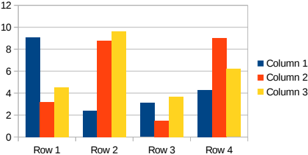

In [12]:
from IPython.display import Image, display

for item, _ in doc_enhanced.iterate_items():
    if item.label == "picture":
        image_data = item.image

        # Get the image URI
        uri = str(image_data.uri)

        # Display the image using IPython
        display(Image(url=uri))
        break

##picture description

In [13]:
# AI-powered content enrichment
pipeline_options = PdfPipelineOptions(
    do_picture_description=True,  # AI-generated image descriptions
    picture_description_options=PictureDescriptionVlmOptions(
        repo_id="HuggingFaceTB/SmolVLM-256M-Instruct",
        prompt="Describe this picture. Be precise and concise.",
    ),
    generate_picture_images=True,
)

converter_enhanced = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
    }
)

result_enhanced = converter_enhanced.convert("/content/file-example_PDF_1MB.pdf")
doc_enhanced = result_enhanced.document
second_picture = doc_enhanced.pictures[1]

print(f"Caption: {second_picture.caption_text(doc=doc_enhanced)}")

# Check for annotations
for annotation in second_picture.annotations:
    print(annotation.text)

[INFO] 2026-06-25 08:45:03,491 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 08:45:03,534 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-06-25 08:45:03,536 [RapidOCR] main.py:63: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-06-25 08:45:03,613 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 08:45:03,620 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-25 08:45:03,620 [RapidOCR] main.py:63: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-25 08:45:03,704 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 08:45:03,784 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/l

KeyboardInterrupt: 

##Element Finder

In [16]:
# Initialize converter with default settings
converter = DocumentConverter()

# Convert any document format - we'll use the Docling technical report itself
source_url = "/content/file-sample_150kB.pdf"
result = converter.convert(source_url)

# Access structured data immediately
doc = result.document
print(f"Successfully processed document from: {source_url}")

from collections import defaultdict

# Create a dictionary to categorize all document elements by type
element_types = defaultdict(list)

# Iterate through all document elements and group them by label
for item, _ in doc.iterate_items():
    element_type = item.label
    element_types[element_type].append(item)

# Display the breakdown of document structure
print("Document structure breakdown:")

[INFO] 2026-06-25 09:25:58,759 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 09:25:58,815 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-06-25 09:25:58,817 [RapidOCR] main.py:63: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-06-25 09:25:58,939 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 09:25:58,949 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-25 09:25:58,952 [RapidOCR] main.py:63: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-25 09:25:59,077 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 09:25:59,219 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/l

Successfully processed document from: /content/file-sample_150kB.pdf
Document structure breakdown:


##Print first element table data

In [17]:
for element_type, items in element_types.items():
    print(f"  {element_type}: {len(items)} elements")
first_table = element_types["table"][0]
print(first_table.export_to_dataframe(doc=doc).to_markdown())

  section_header: 6 elements
  text: 8 elements
  list_item: 6 elements
  picture: 2 elements
  table: 1 elements
|    |    | Lorem ipsum                                             | Lorem ipsum   | Lorem ipsum   |
|---:|---:|:--------------------------------------------------------|:--------------|:--------------|
|  0 |  1 | In eleifend velit vitae libero sollicitudin euismod.    | Lorem         |               |
|  1 |  2 | Cras fringilla ipsum magna, in fringilla dui commodo a. | Ipsum         |               |
|  2 |  3 | Aliquam erat volutpat.                                  | Lorem         |               |
|  3 |  4 | Fusce vitae vestibulum velit.                           | Lorem         |               |
|  4 |  5 | Etiam vehicula luctus fermentum.                        | Ipsum         |               |


##print the first element List data

In [18]:
first_list_items = element_types["list_item"][0:6]
for list_item in first_list_items:
    print(list_item.text)

 Maecenas non lorem quis tellus placerat varius.
 Nulla facilisi.
 Aenean congue fringilla justo ut aliquam.
 Mauris id ex erat. Nunc vulputate neque vitae justo facilisis, non condimentum ante sagittis.
 Morbi viverra semper lorem nec molestie.
 Maecenas tincidunt est efficitur ligula euismod, sit amet ornare est vulputate.


## Docling With RAG

In [19]:
from docling.document_converter import DocumentConverter

# Initialize converter with default settings
converter = DocumentConverter()

# Convert the document into structured data
source_url = "/content/file-sample_150kB.pdf"
result = converter.convert(source_url)

# Access structured data immediately
doc = result.document

[INFO] 2026-06-25 09:34:46,745 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 09:34:46,805 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-06-25 09:34:46,806 [RapidOCR] main.py:63: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-06-25 09:34:46,887 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 09:34:46,893 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-25 09:34:46,894 [RapidOCR] main.py:63: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-25 09:34:46,960 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 09:34:47,032 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/l

In [20]:
def print_chunk(chunk):
    print(f"Chunk length: {len(chunk.text)} characters")
    if len(chunk.text) > 30:
        print(f"Chunk content: {chunk.text[:30]}...{chunk.text[-30:]}")
    else:
        print(f"Chunk content: {chunk.text}")
    print("-" * 50)

In [21]:
from docling.chunking import HybridChunker
from docling_core.transforms.chunker.tokenizer.huggingface import HuggingFaceTokenizer
from transformers import AutoTokenizer

# API update: `overlap_tokens` is no longer a HybridChunker parameter.
# The current API takes a `tokenizer` plus `max_tokens` (optional `merge_peers`).
# We align the tokenizer with the embedding model used in the next cell.
EMBED_MODEL_ID = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = HuggingFaceTokenizer(
    tokenizer=AutoTokenizer.from_pretrained(EMBED_MODEL_ID),
    max_tokens=512,
)
chunker = HybridChunker(tokenizer=tokenizer)

# Create the chunks
rag_chunks = list(chunker.chunk(dl_doc=doc))

print(f"Created {len(rag_chunks)} intelligent chunks")


Token indices sequence length is longer than the specified maximum sequence length for this model (666 > 512). Running this sequence through the model will result in indexing errors


Created 6 intelligent chunks


In [22]:
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings

# Create embeddings
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

# Create the vector store
texts = [chunk.text for chunk in rag_chunks]
vectorstore = FAISS.from_texts(texts, embeddings)

print(f"Built vector store with {len(texts)} chunks")

/tmp/ipykernel_1169/685800125.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


Built vector store with 6 chunks


In [23]:
# Search the knowledge base
query = "How does document processing work?"
relevant_docs = vectorstore.similarity_search(query, k=3)

print(f"Query: '{query}'")
print(f"Found {len(relevant_docs)} relevant chunks:")

for i, doc in enumerate(relevant_docs, 1):
    print(f"\nResult {i}:")
    print(f"Content: {doc.page_content[:150]}...")

Query: 'How does document processing work?'
Found 3 relevant chunks:

Result 1:
Content: 1, Lorem ipsum = In eleifend velit vitae libero sollicitudin euismod.. 1, Lorem ipsum = Lorem. 1, Lorem ipsum = . 2, Lorem ipsum = Cras fringilla ipsu...

Result 2:
Content: In non mauris justo. Duis vehicula mi vel mi pretium, a viverra erat efficitur. Cras aliquam est ac eros varius, id iaculis dui auctor. Duis pretium n...

Result 3:
Content: Maecenas non lorem quis tellus placerat varius. Nulla facilisi. Aenean congue fringilla justo ut aliquam. Mauris id ex erat. Nunc vulputate neque vita...


## Simple PDF to Markdown Conversion
This section converts a single PDF file to Markdown format using the Docling library.

In [27]:
import time
import os

# Change this to a local path or another URL if desired.

# Note: using the default URL requires network access; if offline, provide a
# source = "https://arxiv.org/pdf/2408.09869"

# local file path (e.g., Path("/path/to/file.pdf")).
source = "/content/file-sample_150kB.pdf"

converter = DocumentConverter()

start_time = time.time()
result = converter.convert(source)
end_time = time.time()

# Extract the filename from the source URL
filename = os.path.basename(source)
# Remove the file extension and add .md
output_filename = os.path.splitext(filename)[0] + ".md"

# # Print Markdown to stdout.
# print(result.document.export_to_markdown())

with open(output_filename, "w") as f:
    f.write(result.document.export_to_markdown())

time_taken = end_time - start_time
print(f"Time taken to parse the document: {time_taken:.2f} seconds")

[INFO] 2026-06-25 09:38:49,849 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 09:38:49,885 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-06-25 09:38:49,887 [RapidOCR] main.py:63: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-06-25 09:38:49,968 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 09:38:49,973 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-25 09:38:49,974 [RapidOCR] main.py:63: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-25 09:38:50,057 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 09:38:50,135 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/l

Time taken to parse the document: 25.70 seconds


## Custom Conversion

In [30]:
import json
import logging
import time
from pathlib import Path
import os

from docling.datamodel.accelerator_options import AcceleratorDevice, AcceleratorOptions
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import (
    PdfPipelineOptions,
    RapidOcrOptions,
    TesseractOcrOptions,
    TesseractCliOcrOptions,
)
from docling.document_converter import DocumentConverter, PdfFormatOption
from docling.backend.pypdfium2_backend import PyPdfiumDocumentBackend
from docling.document_converter import DocumentConverter, PdfFormatOption
import os

# from docling.datamodel.pipeline_options import OcrMacOptions   # Uncomment if using macOS OCR
# os.environ["TESSDATA_PREFIX"] = r"C:\Program Files\Tesseract-OCR\"

_log = logging.getLogger(__name__)

# 📝 Helper function to save outputs in separate folder
def export_results(conv_result, folder_name):
    output_dir = Path(folder_name)
    output_dir.mkdir(parents=True, exist_ok=True)
    doc_filename = conv_result.input.file.stem

    with (output_dir / f"{doc_filename}.json").open("w", encoding="utf-8") as fp:
        fp.write(json.dumps(conv_result.document.export_to_dict()))

    with (output_dir / f"{doc_filename}.txt").open("w", encoding="utf-8") as fp:
        fp.write(conv_result.document.export_to_markdown())

    with (output_dir / f"{doc_filename}.md").open("w", encoding="utf-8") as fp:
        fp.write(conv_result.document.export_to_markdown())

    with (output_dir / f"{doc_filename}.doctags").open("w", encoding="utf-8") as fp:
        fp.write(conv_result.document.export_to_doctags())

In [31]:
logging.basicConfig(level=logging.INFO)
input_doc_path = Path("/content/file-sample_150kB.pdf")

# =============================================================
# PyPdfium without EasyOCR
# =============================================================
pipeline_options = PdfPipelineOptions()
pipeline_options.do_ocr = False
pipeline_options.do_table_structure = True
pipeline_options.table_structure_options.do_cell_matching = False

doc_converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(
            pipeline_options=pipeline_options, backend=PyPdfiumDocumentBackend
        )
    }
)

start = time.time()
conv_result = doc_converter.convert(input_doc_path)
print(f"✅ PyPdfium without EasyOCR in {time.time()-start:.2f}s")
export_results(conv_result, "output/PyPdfium_without_EasyOCR")

✅ PyPdfium without EasyOCR in 21.43s


In [32]:
# =============================================================
# PyPdfium with EasyOCR
# =============================================================
pipeline_options = PdfPipelineOptions()
pipeline_options.do_ocr = True
pipeline_options.do_table_structure = True
pipeline_options.table_structure_options.do_cell_matching = True

doc_converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(
            pipeline_options=pipeline_options, backend=PyPdfiumDocumentBackend
        )
    }
)

start = time.time()
conv_result = doc_converter.convert(input_doc_path)
print(f"✅ PyPdfium with EasyOCR in {time.time()-start:.2f}s")
export_results(conv_result, "output/PyPdfium_with_EasyOCR")

[INFO] 2026-06-25 09:41:56,761 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 09:41:56,800 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-06-25 09:41:56,803 [RapidOCR] main.py:63: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-06-25 09:41:56,876 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 09:41:56,882 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-25 09:41:56,883 [RapidOCR] main.py:63: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-25 09:41:56,947 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 09:41:57,021 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/l

✅ PyPdfium with EasyOCR in 24.19s


In [33]:
# =============================================================
# Docling Parse without EasyOCR
# =============================================================
pipeline_options = PdfPipelineOptions()
pipeline_options.do_ocr = False
pipeline_options.do_table_structure = True
pipeline_options.table_structure_options.do_cell_matching = True

doc_converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
    }
)

start = time.time()
conv_result = doc_converter.convert(input_doc_path)
print(f"✅ Docling Parse without EasyOCR in {time.time()-start:.2f}s")
export_results(conv_result, "output/Docling_without_EasyOCR")

✅ Docling Parse without EasyOCR in 23.24s


In [34]:
# =============================================================
# Docling Parse with EasyOCR (default)
# =============================================================
pipeline_options = PdfPipelineOptions()
pipeline_options.do_ocr = True
pipeline_options.do_table_structure = True
pipeline_options.table_structure_options.do_cell_matching = True
pipeline_options.accelerator_options = AcceleratorOptions(
    num_threads=4, device=AcceleratorDevice.AUTO
)

doc_converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
    }
)

start = time.time()
conv_result = doc_converter.convert(input_doc_path)
print(f"✅ Docling Parse with EasyOCR (default) in {time.time()-start:.2f}s")
export_results(conv_result, "output/Docling_EasyOCR_Default")

[INFO] 2026-06-25 09:42:54,263 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 09:42:54,298 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-06-25 09:42:54,299 [RapidOCR] main.py:63: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-06-25 09:42:54,368 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 09:42:54,374 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-25 09:42:54,375 [RapidOCR] main.py:63: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-25 09:42:54,438 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 09:42:54,514 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/l

✅ Docling Parse with EasyOCR (default) in 23.66s


In [35]:
# =============================================================
# Docling Parse with EasyOCR (CPU only)
# =============================================================
pipeline_options = PdfPipelineOptions()
pipeline_options.do_ocr = True
pipeline_options.do_table_structure = True
pipeline_options.table_structure_options.do_cell_matching = True
# pipeline_options.ocr_options.use_gpu = False  # Uncomment to force CPU

doc_converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
    }
)

start = time.time()
conv_result = doc_converter.convert(input_doc_path)
print(f"✅ Docling Parse with EasyOCR (CPU only) in {time.time()-start:.2f}s")
export_results(conv_result, "output/Docling_EasyOCR_CPU")

[INFO] 2026-06-25 09:43:23,772 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 09:43:23,807 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-06-25 09:43:23,809 [RapidOCR] main.py:63: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-06-25 09:43:23,882 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 09:43:23,887 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-25 09:43:23,888 [RapidOCR] main.py:63: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-25 09:43:23,953 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 09:43:24,034 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/l

✅ Docling Parse with EasyOCR (CPU only) in 22.60s


In [36]:
# =============================================================
# Docling Parse with Tesseract CLI
# =============================================================
pipeline_options = PdfPipelineOptions()
pipeline_options.do_ocr = True
pipeline_options.do_table_structure = True
pipeline_options.table_structure_options.do_cell_matching = True
pipeline_options.ocr_options = TesseractCliOcrOptions()

doc_converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
    }
)

start = time.time()
conv_result = doc_converter.convert(input_doc_path)
print(f"✅ Docling Parse with Tesseract CLI in {time.time()-start:.2f}s")
export_results(conv_result, "output/Tesseract_CLI")

✅ Docling Parse with Tesseract CLI in 22.06s


In [37]:
# =============================================================
# Rapid OCR
# =============================================================
pipeline_options = PdfPipelineOptions()
pipeline_options.do_ocr = True
pipeline_options.do_table_structure = True
pipeline_options.table_structure_options.do_cell_matching = True
pipeline_options.ocr_options = RapidOcrOptions()

doc_converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
    }
)

start = time.time()
conv_result = doc_converter.convert(input_doc_path)
print(f"✅ Rapid OCR in {time.time()-start:.2f}s")
export_results(conv_result, "output/Rapid")

[INFO] 2026-06-25 09:45:15,732 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 09:45:15,768 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-06-25 09:45:15,769 [RapidOCR] main.py:63: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-06-25 09:45:15,841 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 09:45:15,847 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-25 09:45:15,848 [RapidOCR] main.py:63: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-25 09:45:15,911 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 09:45:15,985 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/l

✅ Rapid OCR in 24.47s


In [ ]:
# =============================================================
# Docling Parse with ocrmac (macOS only)
# =============================================================
# pipeline_options = PdfPipelineOptions()
# pipeline_options.do_ocr = True
# pipeline_options.do_table_structure = True
# pipeline_options.table_structure_options.do_cell_matching = True
# pipeline_options.ocr_options = OcrMacOptions()
#
# doc_converter = DocumentConverter(
#     format_options={
#         InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
#     }
# )
#
# start = time.time()
# conv_result = doc_converter.convert(input_doc_path)
# print(f"✅ Docling Parse with ocrmac in {time.time()-start:.2f}s")
# export_results(conv_result, "output/OcrMac")

###

## Multi-Format Document Conversion
This section processes multiple document formats (PDF, PPTX, PNG) and converts them to Markdown.

In [3]:
import os
os.mkdir("Multi_scratch")

In [1]:
import json
import logging
from pathlib import Path
import yaml
from docling.backend.pypdfium2_backend import PyPdfiumDocumentBackend
from docling.datamodel.base_models import InputFormat
from docling.document_converter import (
    DocumentConverter,
    PdfFormatOption,
    WordFormatOption,
    ImageFormatOption,
)
from docling.pipeline.simple_pipeline import SimplePipeline
from docling.pipeline.standard_pdf_pipeline import StandardPdfPipeline
from docling.datamodel.pipeline_options import PdfPipelineOptions, TesseractCliOcrOptions
_log = logging.getLogger(__name__)

# Define input document paths
input_doc_paths = [
    Path('/content/file-sample_150kB.pdf'),

    Path('/content/file_example_PNG_500kB.png')
]

# Initialize converter with support for multiple formats
doc_converter = DocumentConverter(
    allowed_formats=[
        InputFormat.PDF,
        InputFormat.IMAGE,
        InputFormat.PPTX,
        InputFormat.DOCX,
        InputFormat.HTML,
        InputFormat.ASCIIDOC,
        InputFormat.CSV,
        InputFormat.MD
    ],
    format_options={
        InputFormat.PDF: PdfFormatOption(
            pipeline_cls=StandardPdfPipeline,
            backend=PyPdfiumDocumentBackend
        ),
        InputFormat.PPTX: WordFormatOption(pipeline_cls=SimplePipeline),
        InputFormat.IMAGE: ImageFormatOption(ocr_options=TesseractCliOcrOptions()), # Explicitly use Tesseract for images
    }
)

# Convert all documents to Markdown
conv_results = doc_converter.convert_all(input_doc_paths)

# Save each converted document as Markdown
for res in conv_results:
        out_path = Path("Multi_scratch")  # ensure this directory exists before running
        print(
            f"Document {res.input.file.name} converted."
            f"\nSaved markdown output to: {out_path!s}"
        )
        _log.debug(res.document._export_to_indented_text(max_text_len=16))
        # Export Docling document to Markdown:
        with (out_path / f"{res.input.file.stem}.md").open("w") as fp:
            fp.write(res.document.export_to_markdown())

[INFO] 2026-06-25 13:06:12,903 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 13:06:12,956 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-06-25 13:06:12,957 [RapidOCR] main.py:63: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-06-25 13:06:13,080 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 13:06:13,087 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-25 13:06:13,088 [RapidOCR] main.py:63: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-25 13:06:13,160 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 13:06:13,262 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/l

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

Document file-sample_150kB.pdf converted.
Saved markdown output to: Multi_scratch


[WARNING] 2026-06-25 13:06:53,481 [RapidOCR] main.py:132: The text detection result is empty


Document file_example_PNG_500kB.png converted.
Saved markdown output to: Multi_scratch


## Figure and Table Extraction
This section extracts figures, tables, and page images from a PDF, saving them as images and data files.

In [2]:
import os
os.mkdir("Figure export_scratch")

In [3]:

import logging
import time
from pathlib import Path
import shutil

from docling_core.types.doc import ImageRefMode, PictureItem, TableItem

from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling.document_converter import DocumentConverter, PdfFormatOption

_log = logging.getLogger(__name__)

IMAGE_RESOLUTION_SCALE = 2.0

In [4]:

logging.basicConfig(level=logging.INFO)

# data_folder = Path(__file__).parent / "../../tests/data"
input_doc_path = Path("/content/file-sample_150kB.pdf")
output_dir = Path("Figure export_scratch")

# Remove the directory if it already exists
if output_dir.exists() and output_dir.is_dir():
    shutil.rmtree(output_dir)


pipeline_options = PdfPipelineOptions()
pipeline_options.images_scale = IMAGE_RESOLUTION_SCALE
pipeline_options.generate_page_images = True
pipeline_options.generate_picture_images = True

doc_converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
    }
)

start_time = time.time()

conv_res = doc_converter.convert(input_doc_path)

output_dir.mkdir(parents=True, exist_ok=True)
doc_filename = conv_res.input.file.stem

# Save page images
for page_no, page in conv_res.document.pages.items():
    page_no = page.page_no
    page_image_filename = output_dir / f"{doc_filename}-{page_no}.png"
    with page_image_filename.open("wb") as fp:
        page.image.pil_image.save(fp, format="PNG")

# Save images of figures and tables
table_counter = 0
picture_counter = 0
for element, _level in conv_res.document.iterate_items():
    if isinstance(element, TableItem):
        table_counter += 1
        element_image_filename = (
            output_dir / f"{doc_filename}-table-{table_counter}.png"
        )
        with element_image_filename.open("wb") as fp:
            element.get_image(conv_res.document).save(fp, "PNG")

    if isinstance(element, PictureItem):
        picture_counter += 1
        element_image_filename = (
            output_dir / f"{doc_filename}-picture-{picture_counter}.png"
        )
        with element_image_filename.open("wb") as fp:
            element.get_image(conv_res.document).save(fp, "PNG")

# Save markdown with embedded pictures
md_filename = output_dir / f"{doc_filename}-with-images.md"
conv_res.document.save_as_markdown(md_filename, image_mode=ImageRefMode.EMBEDDED)

# Save markdown with externally referenced pictures
md_filename = output_dir / f"{doc_filename}-with-image-refs.md"
conv_res.document.save_as_markdown(md_filename, image_mode=ImageRefMode.REFERENCED)

# Save HTML with externally referenced pictures
html_filename = output_dir / f"{doc_filename}-with-image-refs.html"
conv_res.document.save_as_html(html_filename, image_mode=ImageRefMode.REFERENCED)

end_time = time.time() - start_time

_log.info(f"Document converted and figures exported in {end_time:.2f} seconds.")

[INFO] 2026-06-25 13:08:17,135 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 13:08:17,197 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-06-25 13:08:17,198 [RapidOCR] main.py:63: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-06-25 13:08:17,324 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 13:08:17,329 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-25 13:08:17,330 [RapidOCR] main.py:63: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-25 13:08:17,452 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 13:08:17,601 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/l

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

## Forced Full-Page OCR
This section applies full-page OCR to a scanned document or image, forcing text extraction.

In [11]:
from pathlib import Path

from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import (
    PdfPipelineOptions,
    TesseractCliOcrOptions,
)
from docling.document_converter import DocumentConverter, PdfFormatOption


def main():
    # Input file path
    input_doc_path = Path("/content/images.png")

    # Output directory for markdown files
    output_dir = Path("full_figure_ocr")
    output_dir.mkdir(parents=True, exist_ok=True)

    # --- Pipeline configuration ---
    pipeline_options = PdfPipelineOptions()
    pipeline_options.do_ocr = True
    pipeline_options.do_table_structure = True
    pipeline_options.table_structure_options.do_cell_matching = True

    # Any of the OCR options can be used: EasyOcrOptions, TesseractOcrOptions,
    # TesseractCliOcrOptions, OcrMacOptions (macOS only), RapidOcrOptions
    # ocr_options = EasyOcrOptions(force_full_page_ocr=True)
    # ocr_options = TesseractOcrOptions(force_full_page_ocr=True)
    # ocr_options = OcrMacOptions(force_full_page_ocr=True)
    # ocr_options = RapidOcrOptions(force_full_page_ocr=True)
    ocr_options = TesseractCliOcrOptions(force_full_page_ocr=True)
    pipeline_options.ocr_options = ocr_options

    converter = DocumentConverter(
        format_options={
            InputFormat.PDF: PdfFormatOption(
                pipeline_options=pipeline_options,
            )
        }
    )

    # --- Perform conversion ---
    result = converter.convert(input_doc_path)
    doc = result.document

    # Export to Markdown
    md = doc.export_to_markdown()

    # Save Markdown file into the "full_figure_ocr" folder
    output_path = output_dir / f"{input_doc_path.stem}.md"
    output_path.write_text(md, encoding="utf-8")

    print(f"✅ Markdown saved at: {output_path.resolve()}")


if __name__ == "__main__":
    main()

[INFO] 2026-06-25 13:16:53,867 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 13:16:53,956 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-06-25 13:16:53,962 [RapidOCR] main.py:63: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-06-25 13:16:54,399 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 13:16:54,420 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-25 13:16:54,423 [RapidOCR] main.py:63: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-25 13:16:54,662 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 13:16:54,943 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/l

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

✅ Markdown saved at: /content/full_figure_ocr/images.md


## Text Translation
This section translates the extracted text from a PDF to German using Google Translate.

In [7]:
import os
os.mkdir("Simpletranslation_scratch")

In [10]:

import logging
from pathlib import Path

from docling_core.types.doc import ImageRefMode, TableItem, TextItem
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling.document_converter import DocumentConverter, PdfFormatOption
# from googletrans import Translator

# translator = Translator()
_log = logging.getLogger(__name__)

IMAGE_RESOLUTION_SCALE = 2.0


# FIXME: put in your favorite translation code ...
def translate(text: str, src: str = "en", dest: str = "de") -> str:
    """
    Translate text from English to German using Google Translate.
    """
    try:
        # translated = translator.translate(text, src=src, dest=dest)
        # return translated.text
        _log.warning("Translation functionality is currently disabled due to dependency conflicts.")
        return text # Return original text if translation is disabled
    except Exception as e:
        _log.warning(f"Translation failed: {e}")
        return text


def main():
    logging.basicConfig(level=logging.INFO)


    input_doc_path = Path("/content/file-sample_150kB.pdf")
    output_dir = Path("Simpletranslation_scratch")  # ensure this directory exists before saving

    pipeline_options = PdfPipelineOptions()
    pipeline_options.images_scale = IMAGE_RESOLUTION_SCALE
    pipeline_options.generate_page_images = True
    pipeline_options.generate_picture_images = True

    doc_converter = DocumentConverter(
        format_options={
            InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
        }
    )

    conv_res = doc_converter.convert(input_doc_path)
    conv_doc = conv_res.document
    doc_filename = conv_res.input.file.name

    # Save markdown with embedded pictures in original text
    # Tip: create the `scratch/` folder first or adjust `output_dir`.
    md_filename = output_dir / f"{doc_filename}-with-images-orig.md"
    conv_doc.save_as_markdown(md_filename, image_mode=ImageRefMode.EMBEDDED)

    for element, _level in conv_res.document.iterate_items():
        if isinstance(element, TextItem):
            element.orig = element.text
            element.text = translate(text=element.text)

        elif isinstance(element, TableItem):
            for cell in element.data.table_cells:
                cell.text = translate(text=cell.text)

    # Save markdown with embedded pictures in translated text
    md_filename = output_dir / f"{doc_filename}-with-images-translated.md"
    conv_doc.save_as_markdown(md_filename, image_mode=ImageRefMode.EMBEDDED)


if __name__ == "__main__":
    main()

[INFO] 2026-06-25 13:12:02,355 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 13:12:02,393 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-06-25 13:12:02,395 [RapidOCR] main.py:63: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-06-25 13:12:02,503 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 13:12:02,512 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-25 13:12:02,513 [RapidOCR] main.py:63: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-25 13:12:02,608 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-25 13:12:02,685 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/l

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

## Summary
This notebook demonstrates the Docling library's capabilities for document conversion, figure and table extraction, OCR, and translation. Outputs are saved as Markdown, images, CSV, and HTML files.